In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [3]:
df.sample(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
237,15753874,Female,37,80000,0
235,15646227,Male,46,79000,1
35,15713144,Male,35,27000,0
72,15595228,Female,20,23000,0
116,15679297,Male,35,75000,0
216,15636023,Male,49,65000,0
219,15732987,Male,59,143000,1
214,15622478,Male,47,43000,0
39,15782806,Female,27,31000,0
145,15746422,Female,24,89000,0


In [4]:
df = df.iloc[:,2:]

In [5]:
df.sample(10)

,Age,EstimatedSalary,Purchased
317,35,55000,0
67,23,82000,0
201,49,74000,0
144,34,25000,0
284,48,141000,0
352,42,90000,1
18,46,28000,1
395,46,41000,1
73,33,113000,0
3,27,57000,0


# Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis = 1),
                                                    df['Purchased'],
                                                    test_size = 0.3,
                                                    random_state = 0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

# Standard Scaler


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [14]:
X_test

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000
...,...,...
216,49,65000
259,45,131000
49,31,89000
238,46,82000


In [15]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [16]:
X_test_scaled

array([[-0.77101313,  0.49720103],
       [ 0.0133054 , -0.57280368],
       [-0.28081405,  0.15017248],
       [-0.77101313,  0.26584866],
       [-0.28081405, -0.57280368],
       [-1.06513258, -1.44037507],
       [-0.67297331, -1.5849703 ],
       [-0.18277423,  2.14558666],
       [-1.94749093, -0.05226085],
       [ 0.89566375, -0.775237  ],
       [-0.77101313, -0.60172273],
       [-0.96709276, -0.42820845],
       [-0.08473441, -0.42820845],
       [ 0.11134522,  0.20801057],
       [-1.7514113 ,  0.46828198],
       [-0.5749335 ,  1.36477242],
       [-0.08473441,  0.20801057],
       [-1.84945111,  0.43936294],
       [ 1.67998229,  1.74072002],
       [-0.28081405, -1.38253697],
       [-0.28081405, -0.65956082],
       [ 0.89566375,  2.14558666],
       [ 0.30742485, -0.54388463],
       [ 0.89566375,  1.01774386],
       [-1.45729185, -1.2090227 ],
       [ 1.09174339,  2.05882953],
       [-0.96709276,  0.49720103],
       [-0.86905295,  0.29476771],
       [-0.08473441,

In [12]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [18]:
#converting X_train_scaled to a dataframe, currently they are in numpy array


X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [21]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [22]:
 X_test_scaled

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804
...,...,...
115,1.091743,-0.139018
116,0.699584,1.769639
117,-0.672973,0.555039
118,0.797624,0.352606


In [23]:
# applying describe to our original X_train

np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [26]:
# applying describe to our scaled X_train_scaled

np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling

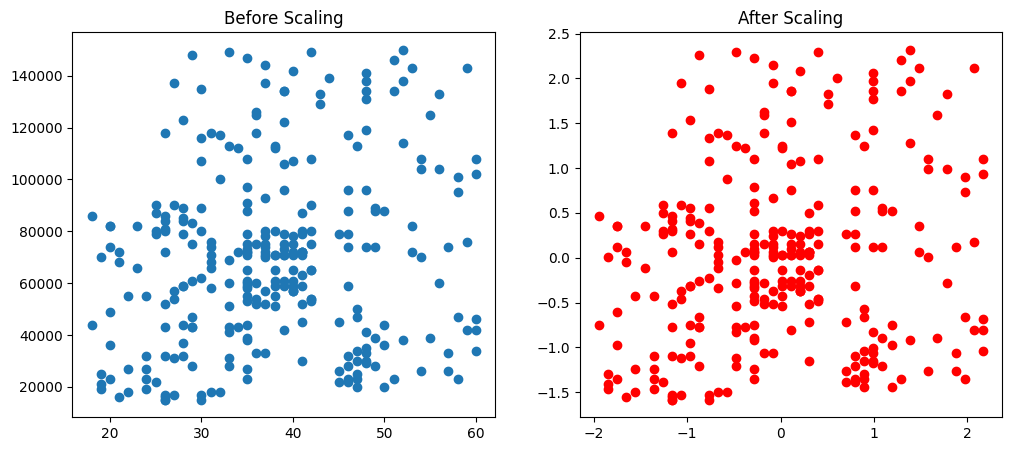

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color = 'red')
ax2.set_title('After Scaling')

plt.show()

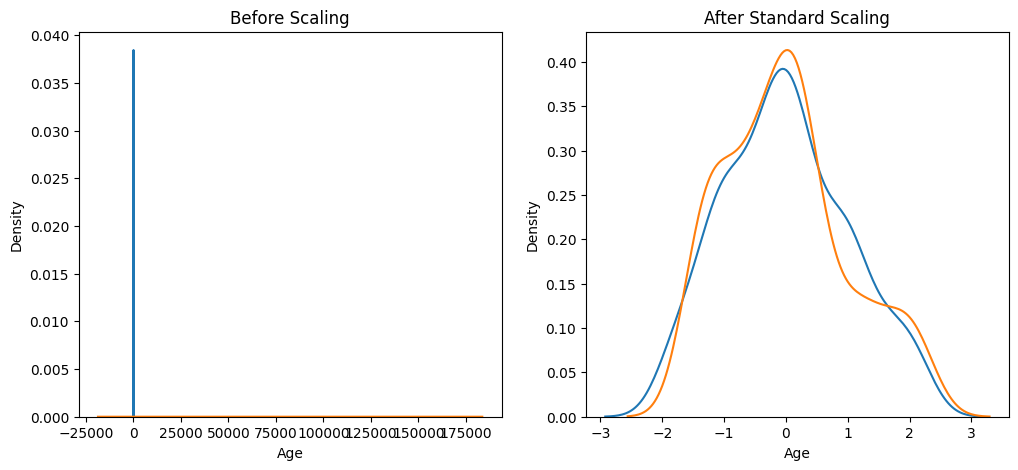

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax =ax2)

plt.show()

# Comparison of Scaling

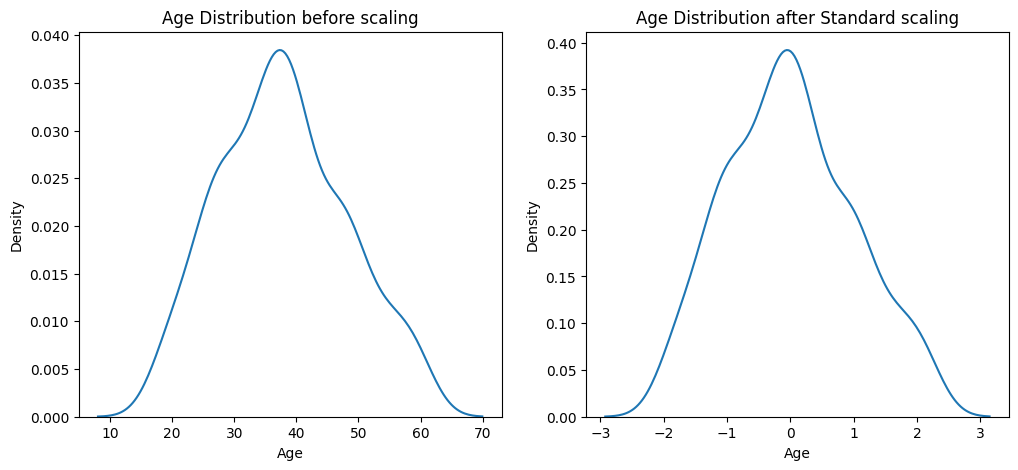

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))

#before scaling
ax1.set_title('Age Distribution before scaling')
sns.kdeplot(X_train['Age'], ax = ax1)

#after scaling
ax2.set_title('Age Distribution after Standard scaling')
sns.kdeplot(X_train_scaled['Age'], ax = ax2)

plt.show()

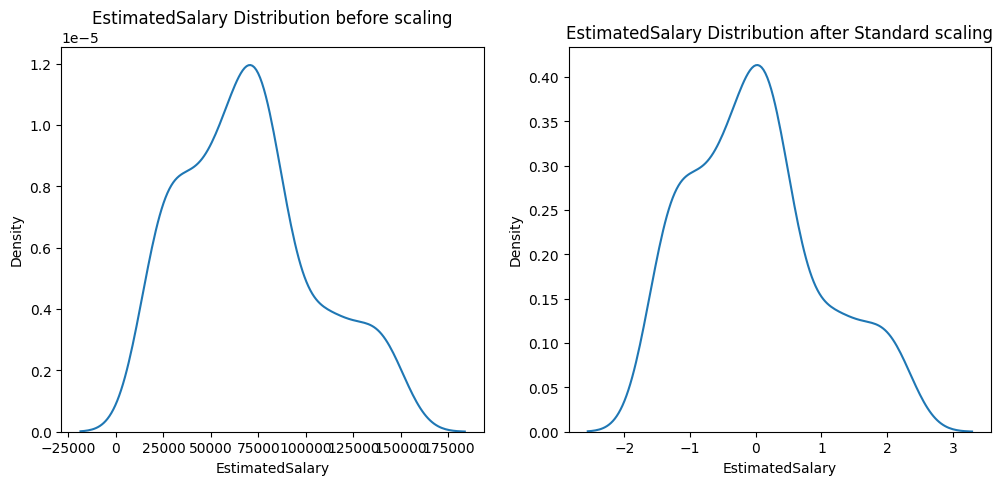

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))

#before scaling
ax1.set_title('EstimatedSalary Distribution before scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

#after scaling
ax2.set_title('EstimatedSalary Distribution after Standard scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)

plt.show()

# Why scaling is important??

In [36]:
from sklearn.linear_model import LogisticRegression


In [37]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [38]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [39]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr.predict(X_test_scaled)

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
print('Actual : ', accuracy_score(y_test, y_pred))
print('Scaled : ', accuracy_score(y_test, y_pred_scaled))

Actual :  0.875
Scaled :  0.6583333333333333


In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [45]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)


DecisionTreeClassifier()

In [46]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [47]:
print('Actual : ', accuracy_score(y_test, y_pred))
print('Scaled : ', accuracy_score(y_test, y_pred_scaled))

Actual :  0.875
Scaled :  0.875


In [48]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000
